# PROJECT : REGRESSION 
# Dataset : Life Expectancy (WHO)
analysis on factors influencing life Expectancy

## Dataset Source

## Data Loading and Initial Exploration 
### Library Imports

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer 
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn .neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score , classification_report , roc_auc_score , roc_curve
import matplotlib.pyplot as plt 
from sklearn.preprocessing import label_binarize
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import plot_model #for model visualization

#from tensorflow.keras.layers import Dense
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.utils import plot_model #for model visualization


from warnings import filterwarnings
filterwarnings('ignore')

### Reading the Data into a pandas Dataframe 

In [2]:
df=pd.read_csv('Life Expectancy Data.csv')
df

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [3]:
#print number of rows and columns in the dataset

print("Number of Rows:",df.shape[0])
print("Number of Features:",df.shape[1])

Number of Rows: 2938
Number of Features: 22


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

## Missing values analysis

**Checking for NULL values in the dataset**

In [5]:
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

## Statistical Info for Numerical Features

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2938.0,2.007519e+03,4.613841e+00,2000.00000,2004.000000,2.008000e+03,2.012000e+03,2.015000e+03
Life expectancy,2928.0,6.922493e+01,9.523867e+00,36.30000,63.100000,7.210000e+01,7.570000e+01,8.900000e+01
Adult Mortality,2928.0,1.647964e+02,1.242921e+02,1.00000,74.000000,1.440000e+02,2.280000e+02,7.230000e+02
infant deaths,2938.0,3.030395e+01,1.179265e+02,0.00000,0.000000,3.000000e+00,2.200000e+01,1.800000e+03
Alcohol,2744.0,4.602861e+00,4.052413e+00,0.01000,0.877500,3.755000e+00,7.702500e+00,1.787000e+01
percentage expenditure,2938.0,7.382513e+02,1.987915e+03,0.00000,4.685343,6.491291e+01,4.415341e+02,1.947991e+04
Hepatitis B,2385.0,8.094046e+01,2.507002e+01,1.00000,77.000000,9.200000e+01,9.700000e+01,9.900000e+01
Measles,2938.0,2.419592e+03,1.146727e+04,0.00000,0.000000,1.700000e+01,3.602500e+02,2.121830e+05
BMI,2904.0,3.832125e+01,2.004403e+01,1.00000,19.300000,4.350000e+01,5.620000e+01,8.730000e+01
under-five deaths,2938.0,4.203574e+01,1.604455e+02,0.00000,0.000000,4.000000e+00,2.800000e+01,2.500000e+03


## Exploring Categorical Features

In [7]:
df['Country'].value_counts()

Country
Afghanistan              16
Albania                  16
Algeria                  16
Angola                   16
Antigua and Barbuda      16
                         ..
Monaco                    1
Marshall Islands          1
Saint Kitts and Nevis     1
San Marino                1
Tuvalu                    1
Name: count, Length: 193, dtype: int64

In [8]:
df['Status'].value_counts()

Status
Developing    2426
Developed      512
Name: count, dtype: int64

## Data Cleaning

### Handling Missing Values

#### As the number of Missing Values is large I will use Imputing Method to fill null values with mean Value

In [9]:
from sklearn.impute import SimpleImputer


imputer = SimpleImputer(missing_values=np.nan, strategy='mean', fill_value=None)

df['Life expectancy ']=imputer.fit_transform(df[['Life expectancy ']])
df['Adult Mortality']=imputer.fit_transform(df[['Adult Mortality']])
df['Alcohol']=imputer.fit_transform(df[['Alcohol']])
df['Hepatitis B']=imputer.fit_transform(df[['Hepatitis B']])
df[' BMI ']=imputer.fit_transform(df[[' BMI ']])
df['Polio']=imputer.fit_transform(df[['Polio']])
df['Total expenditure']=imputer.fit_transform(df[['Total expenditure']])
df['Diphtheria ']=imputer.fit_transform(df[['Diphtheria ']])
df['GDP']=imputer.fit_transform(df[['GDP']])
df['Population']=imputer.fit_transform(df[['Population']])
df[' thinness  1-19 years']=imputer.fit_transform(df[[' thinness  1-19 years']])
df[' thinness 5-9 years']=imputer.fit_transform(df[[' thinness 5-9 years']])
df['Income composition of resources']=imputer.fit_transform(df[['Income composition of resources']])
df['Schooling']=imputer.fit_transform(df[['Schooling']])

In [10]:
df.isnull().sum()

Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
 BMI                               0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
 HIV/AIDS                          0
GDP                                0
Population                         0
 thinness  1-19 years              0
 thinness 5-9 years                0
Income composition of resources    0
Schooling                          0
dtype: int64

In [11]:
df = df.drop_duplicates()


 Country wise Life Expectancy over Years

#### Handling Outliers
First I will draw boxplot to check outliers

In [12]:
# Loop through each column and create a box plot
for column in df.columns:
    fig = px.box(df, y=column, title=f'Box Plot for {column}')
    
    # Update layout to center the title and make it bold
    fig.update_layout(
        title=dict(text=f'<b>Box Plot for {column}</b>', x=0.5),
        boxmode='group'  
    )
    
    #fig.show()

Second, dealing with outliers

In [13]:
cols_to_handle_outliers = [
    'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure',
    'Hepatitis B', 'Measles ', ' BMI ', 'under-five deaths ', 'Polio',
    'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
    ' thinness  1-19 years', ' thinness 5-9 years',
    'Income composition of resources', 'Schooling'
]

# Perform outlier handling for each specified column
for col_name in cols_to_handle_outliers:
    # Calculate quartiles and IQR
    q1 = df[col_name].quantile(0.25)
    q3 = df[col_name].quantile(0.75)
    iqr = q3 - q1

    # Define the lower and upper bounds for outliers
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Replace outliers with the mean value of the column
    df[col_name] = np.where((df[col_name] > upper_bound) | (df[col_name] < lower_bound), np.mean(df[col_name]), df[col_name])

Thirdly I will draw boxplot to check outliers after handling it

In [14]:
for column in df.columns:
    fig = px.box(df, y=column, title=f'Box Plot for {column}')
    
    # Update layout to center the title and make it bold
    fig.update_layout(
        title=dict(text=f'<b>Box Plot for {column}</b>', x=0.5),
        boxmode='group'  
    )
    
    #fig.show()

Data normalisation for 
'Status'

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Status'] = le.fit_transform(df['Status'])  # Developed=0, Developing=1


data visualisation 

In [16]:
fig=px.histogram(df,x='Life expectancy ',template='plotly_dark')
fig.show()

In [17]:
fig=px.line(df.sort_values(by='Year'),x='Year',y='Life expectancy ',animation_frame='Country',animation_group='Year',color='Country',markers=True,template='plotly_dark',title='<b> Country wise Life Expectancy over Years')
fig.show()

**Some important questions to consider in this dataset**

Visualize adult and infant mortality rates for top 10 counties with lowest life expectancy

Does Life Expectancy has positive or negative correlation with eating habits, lifestyle, exercise, smoking, drinking alcohol

What is the impact of schooling on the lifespan of humans?

In [18]:
low_life = df.groupby('Country').mean().nsmallest(10, ['Life expectancy ']).reset_index()
low_life

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Sierra Leone,2007.5,1.0,46.11250,232.861168,27.562500,3.245179,29.105579,82.348952,807.835560,...,76.818774,6.193470,77.290510,1.390789,271.505561,3.336265e+06,7.68125,7.10000,0.361812,8.231250
1,Central African Republic,2007.5,1.0,48.51250,249.574112,16.500000,1.442054,40.905543,80.940461,790.898060,...,82.550188,4.158012,76.638318,1.742103,363.055905,2.016546e+06,7.10625,7.08750,0.335500,6.237500
2,Lesotho,2007.5,1.0,48.78125,157.746670,4.500000,2.243929,82.118913,87.852673,262.412015,...,86.325047,7.137274,88.603010,1.742103,794.523010,1.200528e+06,7.18750,7.06875,0.456813,10.656250
3,Angola,2007.5,1.0,49.01875,328.562500,30.303948,5.669554,102.100268,74.911452,1753.157165,...,76.712594,4.045512,76.787042,1.742103,1975.143045,1.014710e+07,6.19375,6.66875,0.458375,8.505800
4,Malawi,2007.5,1.0,49.89375,202.198002,37.125000,1.149554,25.849706,88.492558,372.636530,...,89.062500,6.197274,88.207755,1.742103,237.504042,6.700263e+06,7.11875,6.98750,0.410625,10.231250
5,Chad,2007.5,1.0,50.38750,227.750000,44.875000,0.673304,32.277320,80.940461,1311.608620,...,78.668915,4.476762,82.324084,1.742103,484.791694,4.114092e+06,7.14375,7.04375,0.355847,6.087500
6,Côte d'Ivoire,2007.5,1.0,50.38750,303.361168,30.303948,2.947679,0.000000,76.610115,862.060075,...,75.381274,5.736762,73.582755,1.742103,7483.158469,1.275338e+07,6.73750,6.69375,0.627551,11.992793
7,Zimbabwe,2007.5,1.0,50.48750,197.823002,26.562500,4.489554,20.364271,79.680058,615.611045,...,80.346887,6.144887,79.895255,1.742103,410.980194,8.021343e+06,7.01250,6.98750,0.439125,9.825000
8,Swaziland,2007.5,1.0,51.32500,201.361168,2.625000,4.472054,278.099713,89.488836,49.125000,...,89.000000,7.223012,88.332755,1.742103,2165.090837,4.573031e+05,6.47500,6.63125,0.515687,10.350000
9,Nigeria,2007.5,1.0,51.35625,248.500000,30.303948,8.393929,85.444275,79.819182,2312.367725,...,77.947028,3.849887,77.513318,1.742103,1360.139877,1.152996e+07,10.41875,10.36875,0.524263,9.000000


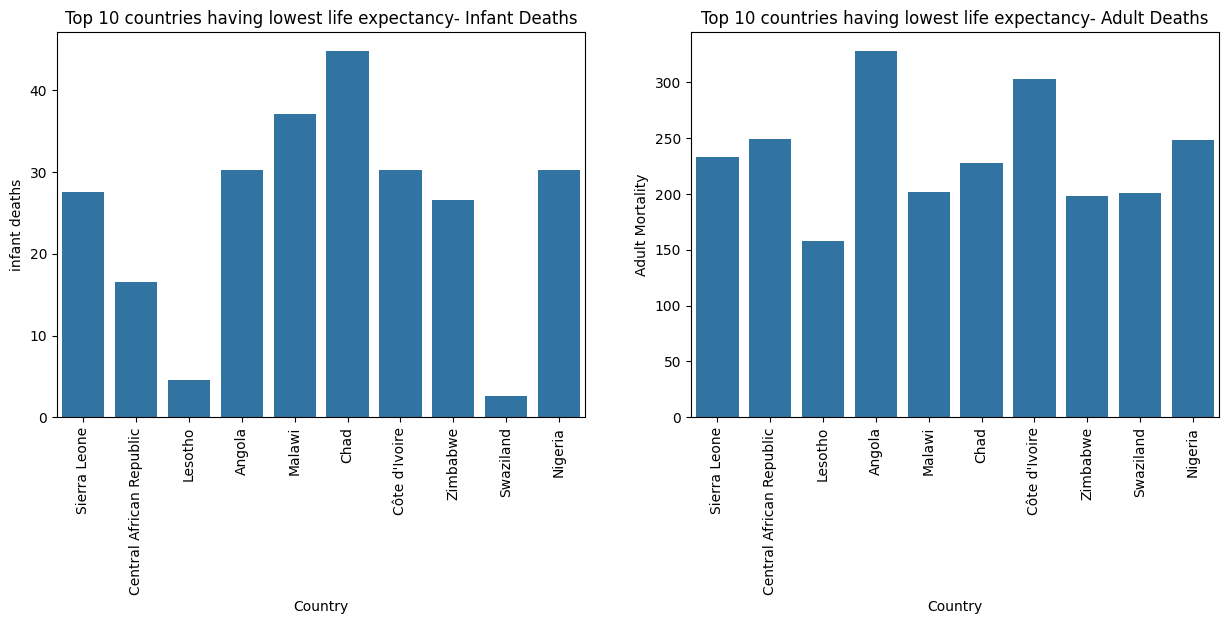

In [19]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
infant = sns.barplot(data = low_life, x = low_life.Country, y = low_life['infant deaths'])
infant.set_title("Top 10 countries having lowest life expectancy- Infant Deaths")
infant.set_xticklabels(infant.get_xticklabels(), rotation = 90)

plt.subplot(1,2,2)
adult = sns.barplot(data = low_life, x = low_life.Country, y = low_life['Adult Mortality'])
adult.set_title("Top 10 countries having lowest life expectancy- Adult Deaths")
adult.set_xticklabels(adult.get_xticklabels(), rotation = 90)


plt.show()


From the bar plots above and by taking the mean, we can infer that the average Life Expectancy is more for the countries that have many years of schooling as compared to those that have very few schooling years

**Dropping unwanted columns**
We drop the column 'Country' as it will no longer be needed for running the models. There are too many country names, hence high cardinality and we cannot create one hot vector for this colum

In [20]:
df.drop('Country', axis = 1, inplace = True)

Correlation analysis

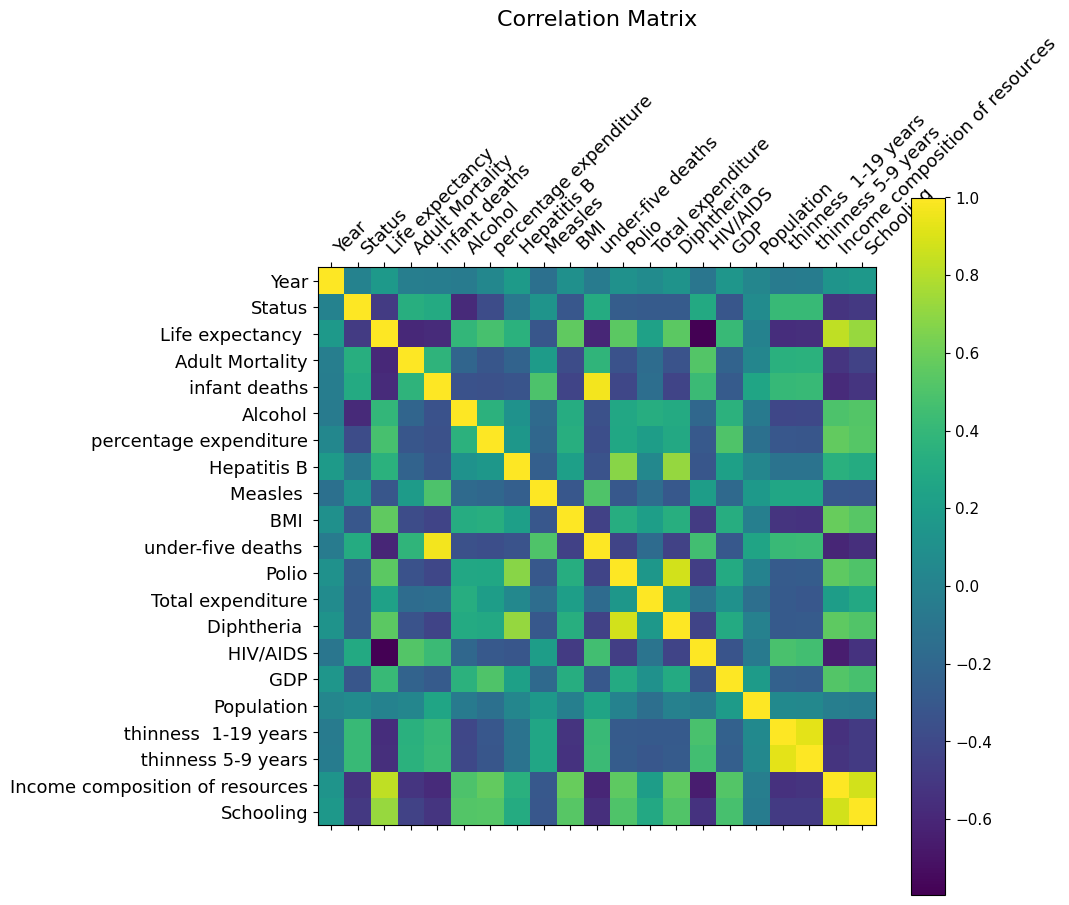

In [21]:
f = plt.figure(figsize=(9, 9))
plt.matshow(df.corr(), fignum=f.number)
plt.xticks(range(df.select_dtypes(['number']).shape[1]), df.select_dtypes(['number']).columns, fontsize=13, ha="left", rotation=45)
plt.yticks(range(df.select_dtypes(['number']).shape[1]), df.select_dtypes(['number']).columns, fontsize=13)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=11)
plt.title('Correlation Matrix', fontsize=16);

The following features are highly correlated:

Under 5 deaths <---> Infant Deaths. Hence we will remove the feature under 5 deaths
Thinness 5-9 <---> Thinness 1-19. Hence we will remove the heature Thinness 5-9

In [22]:
df.drop(columns=['under-five deaths ',' thinness  1-19 years'],axis =1, inplace=True)

Split and Train the data 

In [23]:
X = df.drop('Life expectancy ', axis=1)
y = df['Life expectancy ']

In [24]:
X

,Year,Status,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 5-9 years,Income composition of resources,Schooling
0,2015,1,263.000000,30.303948,0.01,71.279624,65.000000,2419.59224,19.1,82.550188,8.16,65.0,0.100000,584.259210,1.275338e+07,4.870317,0.479,10.1
1,2014,1,271.000000,30.303948,0.01,73.523582,62.000000,492.00000,18.6,58.000000,8.18,62.0,0.100000,612.696514,3.275820e+05,4.870317,0.476,10.0
2,2013,1,268.000000,30.303948,0.01,73.219243,64.000000,430.00000,18.1,62.000000,8.13,64.0,0.100000,631.744976,1.275338e+07,4.870317,0.470,9.9
3,2012,1,272.000000,30.303948,0.01,78.184215,67.000000,2419.59224,17.6,67.000000,8.52,67.0,0.100000,669.959000,3.696958e+06,4.870317,0.463,9.8
4,2011,1,275.000000,30.303948,0.01,7.097109,68.000000,2419.59224,17.2,68.000000,7.87,68.0,0.100000,63.537231,2.978599e+06,4.870317,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,2004,1,164.796448,27.000000,4.36,0.000000,68.000000,31.00000,27.1,67.000000,7.13,65.0,1.742103,454.366654,1.277751e+07,9.400000,0.407,9.2
2934,2003,1,164.796448,26.000000,4.06,0.000000,80.940461,2419.59224,26.7,82.550188,6.52,68.0,1.742103,453.351155,1.263390e+07,9.900000,0.418,9.5
2935,2002,1,73.000000,25.000000,4.43,0.000000,73.000000,304.00000,26.3,73.000000,6.53,71.0,1.742103,57.348340,1.255250e+05,1.300000,0.427,10.0
2936,2001,1,164.796448,25.000000,1.72,0.000000,76.000000,529.00000,25.9,76.000000,6.16,75.0,1.742103,548.587312,1.236616e+07,1.700000,0.427,9.8


We are using the MinMax Scaler for our dataset to bring all values within the range 0-1. The dataset is not sparse and has a good amount of continuous columns. However, some columns have values in thousands, some in hundreds and some 0 and 1. The featureset is comprised of different scales of continuous valued colums. As explained for the Boston Housing data which has a similar structre, we have used MinMax scaler

In [25]:
# Columns to scale
cols_to_scale = [ 'Year', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
        ' thinness 5-9 years',
       'Income composition of resources', 'Schooling']

# Apply Min-Max scaling to the specified columns
scaler = MinMaxScaler()
X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

In [26]:
X

,Year,Status,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 5-9 years,Income composition of resources,Schooling
0,1.000000,1,0.578366,0.550981,0.000000,0.065265,0.150000,1.000000,0.209733,0.657296,0.686949,0.291667,0.000000,0.032752,0.408423,0.309761,0.325180,0.360000
1,0.933333,1,0.596026,0.550981,0.000000,0.067320,0.075000,0.203340,0.203940,0.145833,0.688713,0.229167,0.000000,0.034350,0.010490,0.309761,0.320863,0.353333
2,0.866667,1,0.589404,0.550981,0.000000,0.067041,0.125000,0.177716,0.198146,0.229167,0.684303,0.270833,0.000000,0.035421,0.408423,0.309761,0.312230,0.346667
3,0.800000,1,0.598234,0.550981,0.000000,0.071587,0.200000,1.000000,0.192352,0.333333,0.718695,0.333333,0.000000,0.037570,0.118393,0.309761,0.302158,0.340000
4,0.733333,1,0.604857,0.550981,0.000000,0.006498,0.225000,1.000000,0.187717,0.354167,0.661376,0.354167,0.000000,0.003477,0.095388,0.309761,0.289209,0.320000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,0.266667,1,0.361582,0.490909,0.262523,0.000000,0.225000,0.012812,0.302433,0.333333,0.596120,0.291667,0.965943,0.025449,0.409196,0.603896,0.221583,0.300000
2934,0.200000,1,0.361582,0.472727,0.244418,0.000000,0.548512,1.000000,0.297798,0.657296,0.542328,0.354167,0.965943,0.025392,0.404596,0.636364,0.237410,0.320000
2935,0.133333,1,0.158940,0.454545,0.266747,0.000000,0.350000,0.125641,0.293163,0.458333,0.543210,0.416667,0.965943,0.003130,0.004019,0.077922,0.250360,0.353333
2936,0.066667,1,0.361582,0.454545,0.103199,0.000000,0.425000,0.218632,0.288528,0.520833,0.510582,0.500000,0.965943,0.030746,0.396022,0.103896,0.250360,0.340000


Train/Test split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:

print("X_train shape: ",X_train.shape)
print("y_train shape: ",y_train.shape)
print("X_test shape: ",X_test.shape)
print("y_test shape",y_test.shape)


X_train shape:  (2350, 18)
y_train shape:  (2350,)
X_test shape:  (588, 18)
y_test shape (588,)


MODELS and MODELS EVALUATION

 KNN Regressor
 
KNN regressor is used to find the number of neighbours which with help us determine the y_predicted (predicted life expectancy) value for an instance in the dataset. The chosen n should maximize the train and test scores, have a small difference bwteen them, have a good R2 score and minimize the MSE.

  File "C:\Users\BIG BOX\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Text(0, 0.5, 'Accuracy')

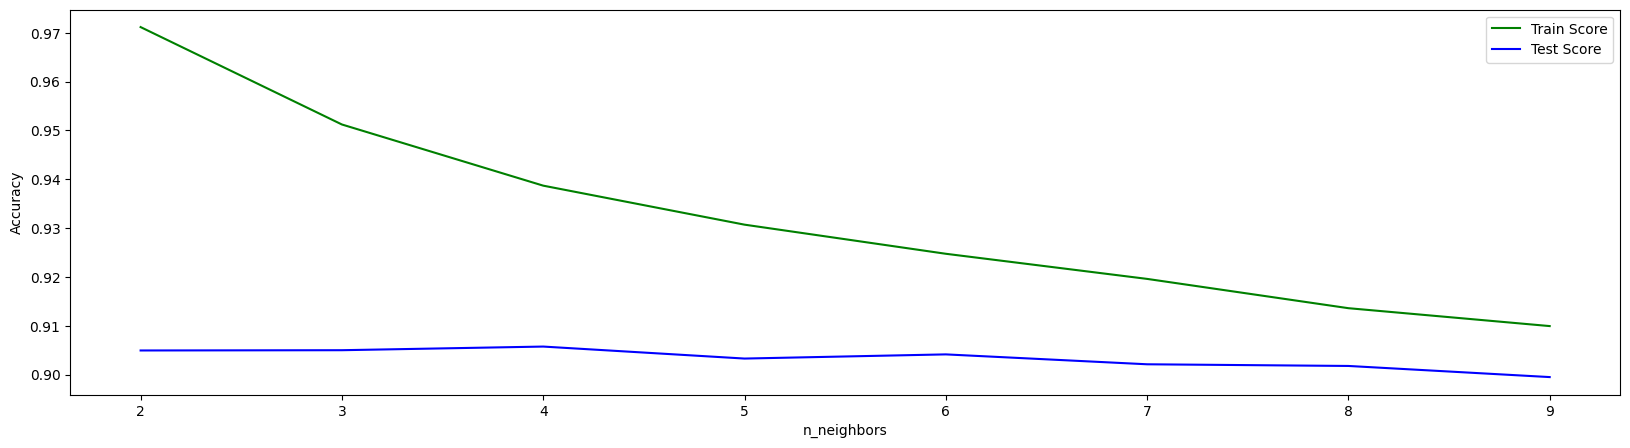

In [29]:
from sklearn.neighbors import KNeighborsRegressor
%matplotlib inline
train_score_array = []
test_score_array = []

for k in range(2,10):
    knn_reg = KNeighborsRegressor(k)
    knn_reg.fit(X_train, y_train)
    train_score_array.append(knn_reg.score(X_train, y_train))
    test_score_array.append(knn_reg.score(X_test, y_test))

x_axis = range(2,10)
plt.subplots(figsize = (20,5))
plt.plot(x_axis, train_score_array, c = 'g', label = 'Train Score')
plt.plot(x_axis, test_score_array, c = 'b', label = 'Test Score')
plt.legend()
plt.xlabel('n_neighbors')
plt.ylabel('Accuracy')


We can see that the train and test score is relatively high when the n_neighbours is 3. Also considering that the difference between the train and test score is lower compared to other values of k

In [30]:
train_score_np = np.array(train_score_array)
test_score_np = np.array(test_score_array)
print('Train score',train_score_array)
print('Test score',test_score_array)
difference = train_score_np - test_score_np
print('Difference',difference)

Train score [0.9711567622208953, 0.9512095008307461, 0.9386843224454875, 0.9306960325325292, 0.9247335092932745, 0.9195879900137559, 0.9135898711679485, 0.9099252568602496]
Test score [0.904929970298607, 0.9049847099354106, 0.905730212150346, 0.9032745898042407, 0.9041287288046054, 0.9021021361765378, 0.9017599671944765, 0.899481123164309]
Difference [0.06622679 0.04622479 0.03295411 0.02742144 0.02060478 0.01748585
 0.0118299  0.01044413]



**Selecting number of neighbours=3 randomly**

In [31]:
knn_reg = KNeighborsRegressor(3)
knn_reg.fit(X_train, y_train)
y_predicted = knn_reg.predict(X_test)

print("train score: {:.4f}".format(knn_reg.score(X_train, y_train)))
print("test score: {:.4f}".format(knn_reg.score(X_test, y_test)))
print('difference: {:.4f}'.format((knn_reg.score(X_train, y_train)) - (knn_reg.score(X_test, y_test))))

train score: 0.9512
test score: 0.9050
difference: 0.0462



We can also use the GridSearchCV to find the best hyperparameters(in KNN case k or number of nearest neighbours) for the model

In [32]:
param_grid_knn = {'n_neighbors':range(2,10), 'weights':['distance','uniform'],'p': [1,2]}
print("Parameter grid:\n{}".format(param_grid_knn))

from sklearn.model_selection import GridSearchCV
grid_search_knn = GridSearchCV(estimator=knn_reg, param_grid=param_grid_knn, return_train_score=True, cv=7)
grid_search_knn.fit(X_train, y_train)

print("Best parameters: {}".format(grid_search_knn.best_params_))

Parameter grid:
{'n_neighbors': range(2, 10), 'weights': ['distance', 'uniform'], 'p': [1, 2]}


Best parameters: {'n_neighbors': 3, 'p': 1, 'weights': 'distance'}


Using the Grid Search CV, we have got best parameters as k=3 and weights=distance. For regression, the cost function is the MSE and the metric to check the best fit of the model is R2 score

In [33]:
from sklearn import metrics
#from sklearn.metrics import mean_squared_error
knn_reg_best = KNeighborsRegressor(n_neighbors =3 , weights = 'distance', p=1)
knn_reg_best.fit(X_train, y_train)
y_predicted = knn_reg_best.predict(X_test)

print('Train score: {:.4f}'.format(knn_reg_best.score(X_train, y_train)))
print('Test score: {:.4f}'.format(knn_reg_best.score(X_test, y_test)))
print("R2_score: {:.4f} ".format(metrics.r2_score(y_test,y_predicted)))
MSE = np.square(np.subtract(y_test,y_predicted)).mean()
print('MSE: {:.4f}'.format(MSE))

#There seems to be some data leakage as the train score is a perfect 1. Hence, although this has high scores and low MSE, we won't consider this as the best model

Train score: 1.0000
Test score: 0.9476
R2_score: 0.9476 
MSE: 4.5413


**Finding the average Training and Testing Score using Cross Validation**

In [34]:
from sklearn.model_selection import cross_val_score

train_cvscore = cross_val_score(knn_reg_best, X_train, y_train, cv=7)
print(train_cvscore)

#Average Cross Validation Score for Train Set
print("The average cross validated train score is: {:.4f}".format(train_cvscore.mean()))

[0.92969834 0.95709768 0.92910093 0.93678994 0.9348673  0.94754289
 0.92696435]
The average cross validated train score is: 0.9374


In [35]:
test_cvscore = cross_val_score(knn_reg, X_test, y_test, cv=7)
print(test_cvscore)

#Average Cross Validation Score for Train Set
print("The average cross validated test score is: {:.4f}".format(test_cvscore.mean()))

[0.85952367 0.82273195 0.86867896 0.87382491 0.84670081 0.86068334
 0.78603705]
The average cross validated test score is: 0.8455


**Using the best fit KNN regressor that we got above k=3, we were able to minimize the MSE and get a high R2 score of 0.93. Let's fit this chosen KNN regressor to the Adult Mortality Feature**

In [36]:
np.where(X.columns == 'Adult Mortality')

(array([2]),)

Text(0.5, 0, 'ADULT MORTALITY')

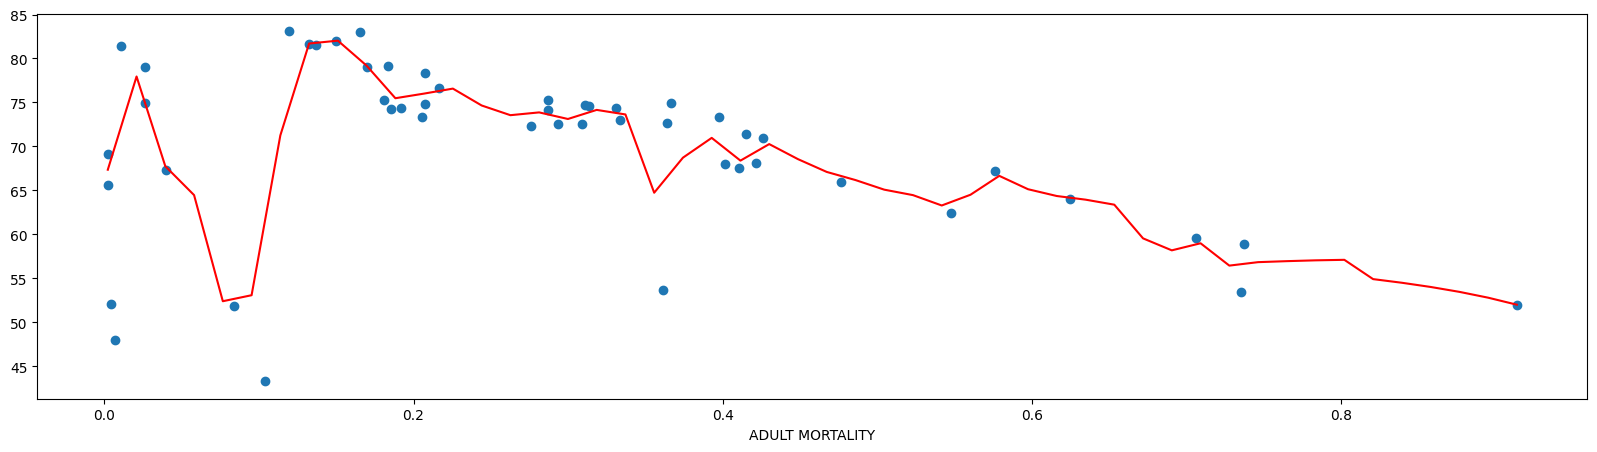

In [37]:
X_b = X_train[['Adult Mortality']].iloc[:50].values
y_b = y_train[:50]

knn_reg = KNeighborsRegressor(n_neighbors =3 , weights = 'distance', p=1)
knn_reg.fit(X_b, y_b)

X_new=np.linspace(X_b.min(), X_b.max(), 50).reshape(50, 1)
y_predict = knn_reg.predict(X_new)

plt.subplots(figsize = (20,5))
plt.plot(X_new, y_predict, c = 'r')
plt.scatter(X_b, y_b)
plt.xlabel('ADULT MORTALITY')

We can see that our chosen KNN Regressor fits this feature well. We can also see that there is one point within the sample which pulls the regressor towards 0.8. If this point were to be removed, we would hace the regressor fitting and ending at the point between 0.5 and 0.6

Linear regression

In [38]:
from sklearn.linear_model import LinearRegression

lreg = LinearRegression()
lreg.fit(X_train, y_train)
print('Train Score: {:.4f}'.format(lreg.score(X_train, y_train)))
print('Test Score:{:.4f}'.format(lreg.score(X_test, y_test)))

Train Score: 0.8354
Test Score:0.8550


We have found the train and test scores for the linear regression model. Let's also find the R2 score and MSE when you use the LReg model on the dataset

In [39]:
from sklearn import metrics

ylinear_predicted = lreg.predict(X_test)

print('MSE:', metrics.mean_squared_error(y_test,ylinear_predicted))
print('R2_score: {:.4f}'.format(metrics.r2_score(y_test,ylinear_predicted)))

MSE: 12.563975574029602
R2_score: 0.8550


We're plotting the number of schooling years across the life expectancy. There is clearly a linear upward trend i.e more the number of years of schooling, higher will be the average life expectancy. We have fit a linear model represented by the red line

Text(0, 0.5, 'Life Expectancy')

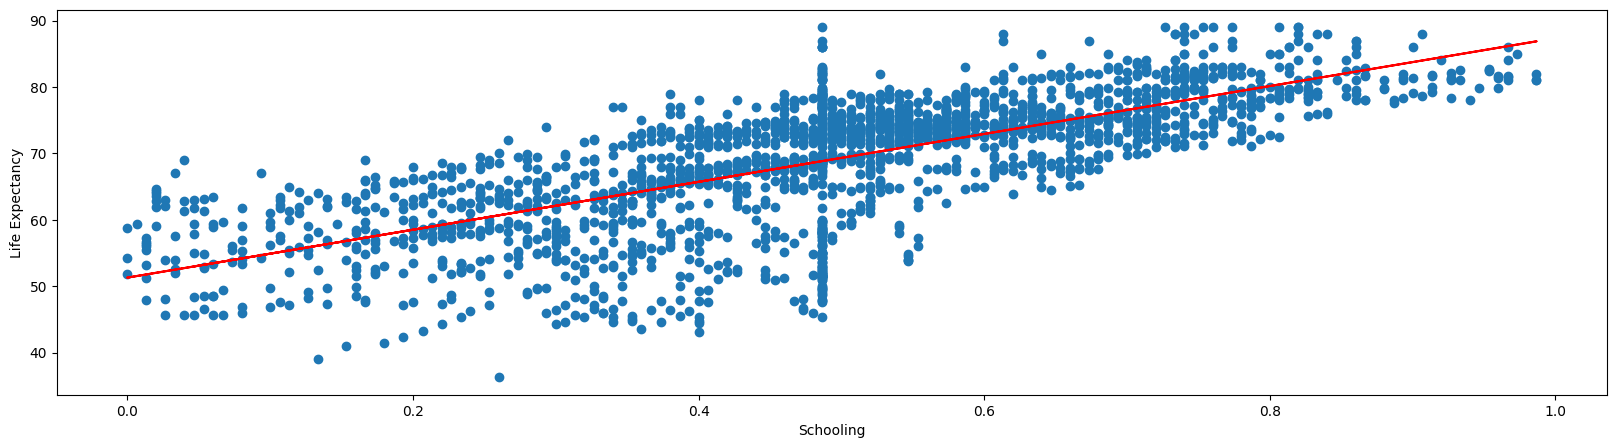

In [40]:
%matplotlib inline
import matplotlib.pyplot as plt

 
X_train_school = X_train[['Schooling']]
lreg.fit(X_train_school, y_train)
y_predict_lifexp = lreg.predict(X_train_school)

plt.subplots(figsize = (20,5))
plt.plot(X_train_school, y_predict_lifexp, c = 'r')
plt.scatter(X_train_school,y_train)
plt.xlabel('Schooling')
plt.ylabel('Life Expectancy')

**Using Grid Search to find the best hyperparameters**

In [41]:
#To find the hyperparameter list of a model
lreg = LinearRegression()
lreg_params = lreg.get_params()
print(f'Default Linear Reg hyperparameters: {lreg_params}')

Default Linear Reg hyperparameters: {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}


In [42]:
param_grid_lin = {'copy_X': [True,False], 'fit_intercept': [True,False]}
print("Parameter grid:\n{}".format(param_grid_lin))

from sklearn.model_selection import GridSearchCV
grid_search_lin = GridSearchCV(estimator=lreg, param_grid=param_grid_lin, return_train_score=True, n_jobs=None, cv=7)
grid_search_lin.fit(X_train, y_train)

print("Best parameters: {}".format(grid_search_lin.best_params_))

Parameter grid:
{'copy_X': [True, False], 'fit_intercept': [True, False]}
Best parameters: {'copy_X': True, 'fit_intercept': True}


The above are the best parameters for the Simple Linear Regression Model. Let's apply these hyperparameters to the training and test datasets to find the R2 score, MSE

In [43]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
lreg_best = LinearRegression(copy_X=True, fit_intercept=True)
lreg_best.fit(X_train, y_train)
ylin_predicted = lreg_best.predict(X_test)

print('Train score: {:.4f}'.format(lreg_best.score(X_train, y_train)))
print('Test score: {:.4f}'.format(lreg_best.score(X_test, y_test)))
print('R2_score: {:.4f}'.format(r2_score(y_test,ylin_predicted)))
MSE = np.square(np.subtract(y_test,ylin_predicted)).mean()
print('MSE: {:.4f}'.format(MSE))

Train score: 0.8354
Test score: 0.8550
R2_score: 0.8550
MSE: 12.5640


We can see that there is not much change in the scores and errors using default parameters and with using best parameters

POLYNOMIAL REGRESSION

In [44]:
from  sklearn.preprocessing  import PolynomialFeatures
train_score_list_poly = []
test_score_list_poly = []

for i in range(1,4):
    poly = PolynomialFeatures(i)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    poly_reg = LinearRegression()
    poly_reg.fit(X_train_poly, y_train)
    train_score_list_poly.append(poly_reg.score(X_train_poly, y_train))
    test_score_list_poly.append(poly_reg.score(X_test_poly, y_test)) 

In [45]:
print(train_score_list_poly)
print(test_score_list_poly)

[0.8353520935221994, 0.9033881108918823, 0.9824492134909055]
[0.8549785258093336, 0.9014839122770693, 0.6075476929268933]


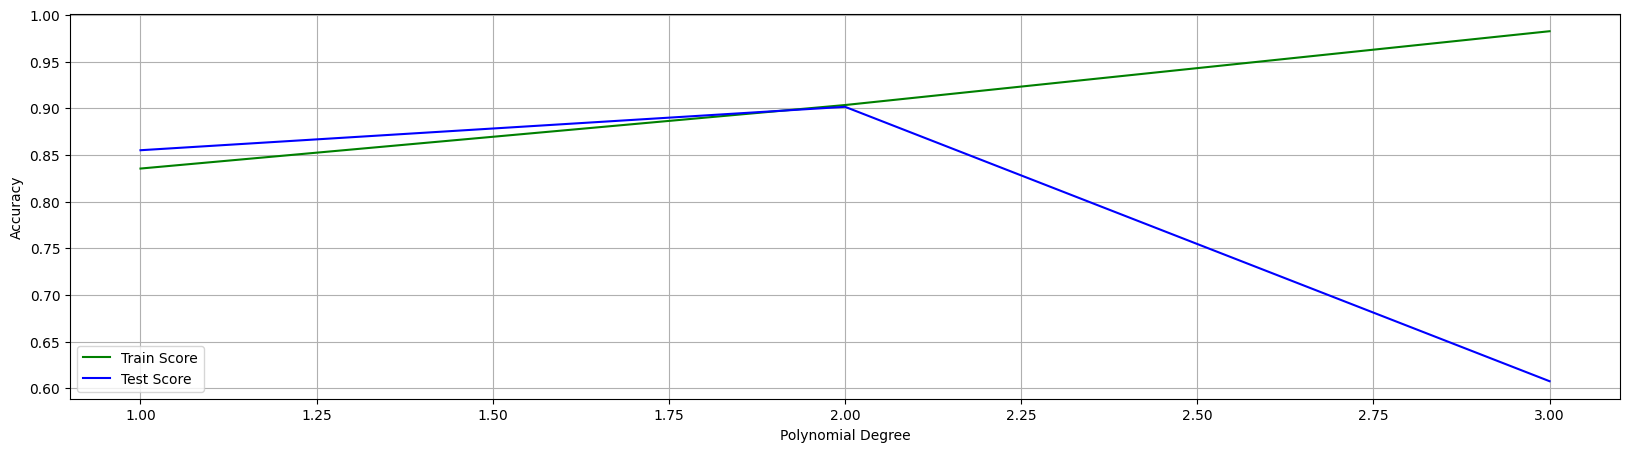

In [46]:
#Visualizing values of the hyperparamters i.e polynomial degree for Polynomial Features model to see which could be best
%matplotlib inline
import matplotlib.pyplot as plt

plt.subplots(figsize = (20,5))
plt.plot(range(1,4), train_score_list_poly, c = 'g', label = 'Train Score')
plt.plot(range(1,4), test_score_list_poly, c = 'b', label = 'Test Score')
plt.legend(loc = 3)
plt.xlabel('Polynomial Degree')
plt.ylabel('Accuracy')
plt.grid()


The train and test scores are high for polynomial of degrees 1 and 2. Test score starts deteriorating after 2


Let's plot Polynomail Feature(2) model on 2 features - y axis Life Expectancy and x-axis Schooling. We should see a curve as model

Text(0, 0.5, 'Life Expectancy')

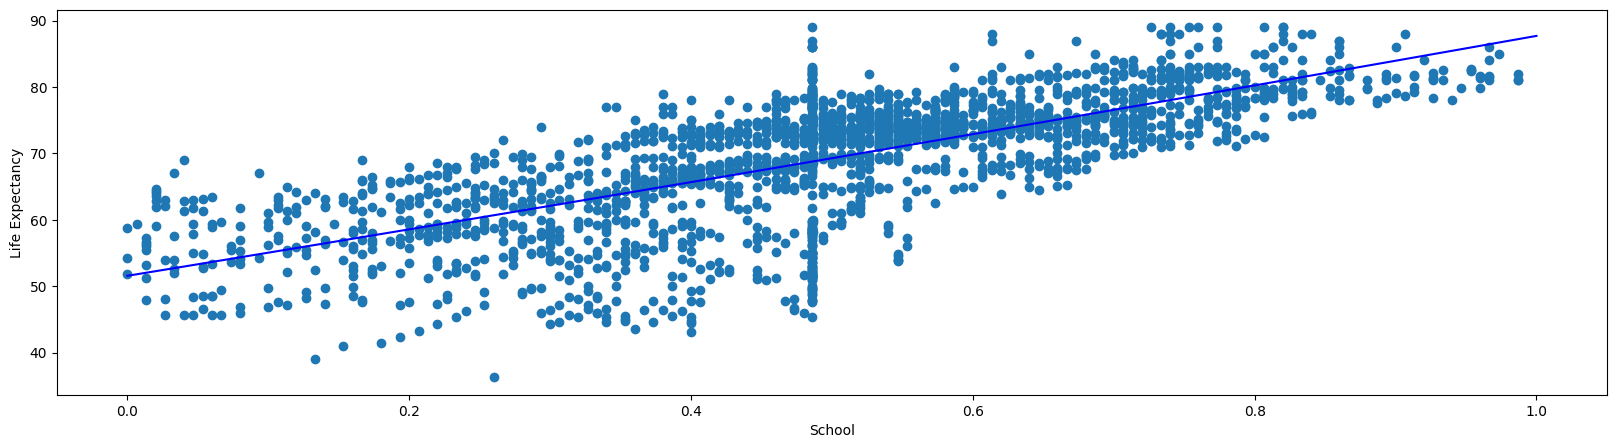

In [47]:

%matplotlib inline
import matplotlib.pyplot as plt

X_train_school = X_train.iloc[:, 17].values.reshape(-1, 1)
poly = PolynomialFeatures(2)
school_Xtrain_poly = poly.fit_transform(X_train_school)
lreg.fit(school_Xtrain_poly, y_train)

x_axis = np.linspace(0,1,100).reshape(-1,1)
x_poly = poly.transform(x_axis)
y_predict_lifexp = lreg.predict(x_poly)


plt.subplots(figsize = (20,5))
plt.plot(x_axis, y_predict_lifexp, c = 'b')
plt.scatter(X_train_school,y_train)
plt.xlabel('School')
plt.ylabel('Life Expectancy')

In [48]:
poly = PolynomialFeatures(2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
poly_reg.fit(X_train_poly, y_train)

y_poly_predicted = poly_reg.predict(X_test_poly)

print('Train score: {:.4f}'.format(poly_reg.score(X_train_poly, y_train)))
print('Test score: {:.4f}'.format(poly_reg.score(X_test_poly, y_test)))

print('R2_score: {:.4f}'.format(r2_score(y_test,y_poly_predicted)))
MSE = np.square(np.subtract(y_test,y_poly_predicted)).mean()
print('MSE: {:.4f}'.format(MSE))

Train score: 0.9034
Test score: 0.9015
R2_score: 0.9015
MSE: 8.5350



Using grid search to find the best hyperparameters for polynomial regression

In [49]:
#We have used Naive Grid Search to find the best hyperparams
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score 
degrees = [2, 3, 4] # Change degree "hyperparameter" here
normalizes = [True, False] # Change normalize hyperparameter here
best_score = 0
best_degree = 0
for degree in degrees:
    for normalize in normalizes:
        poly_features = PolynomialFeatures(degree = degree)
        X_train_poly = poly_features.fit_transform(X_train)
        polynomial_regressor = LinearRegression()
        polynomial_regressor.fit(X_train_poly, y_train)
        scores = cross_val_score(polynomial_regressor, X_train_poly, y_train, cv=5) # Change k-fold cv value here
        if max(scores) > best_score:
            best_score = max(scores)
            best_degree = degree
            best_normalize = normalize

(best_degree)

2

In [50]:
best_score

np.float64(0.8948733136924852)

In [51]:


best_normalize

True

In [52]:


best_poly_reg = PolynomialFeatures(degree=2)
X_train_poly = best_poly_reg.fit_transform(X_train)
X_test_poly = best_poly_reg.transform(X_test)
lreg_poly=LinearRegression(copy_X= True, fit_intercept=True)
lreg_poly.fit(X_train_poly, y_train)

y_pred_poly=lreg_poly.predict(X_test_poly)

print('Train score: {:.4f}'.format(lreg_poly.score(X_train_poly, y_train)))
print('Test score: {:.4f}'.format(lreg_poly.score(X_test_poly, y_test)))


print('R2_score: {:.4f}'.format(r2_score(y_test,y_pred_poly)))
MSE = np.square(np.subtract(y_test,y_pred_poly)).mean()
print('MSE: {:.4f}'.format(MSE))

Train score: 0.9034
Test score: 0.9015
R2_score: 0.9015
MSE: 8.5350


In [53]:
train_cvscore_poly = cross_val_score(polynomial_regressor, X_train, y_train, cv=7)
print(train_cvscore_poly)

#Average Cross Validation Score for Train Set
print("The average cross validated train score is: {:.4f}".format(train_cvscore_poly.mean()))

[0.83948493 0.82655946 0.83024208 0.83404702 0.82295904 0.8508718
 0.81279683]
The average cross validated train score is: 0.8310


In [54]:
test_cvscore_poly = cross_val_score(polynomial_regressor, X_test, y_test, cv=7)
print(test_cvscore_poly)

#Average Cross Validation Score for Test Set
print("The average cross validated test score is: {:.4f}".format(test_cvscore_poly.mean()))

[0.83600805 0.88161449 0.84047339 0.82601909 0.82686795 0.87084055
 0.83723217]
The average cross validated test score is: 0.8456


## Ranom forest


In [55]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import root_mean_squared_error

In [56]:
rf = RandomForestRegressor()

In [57]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Randomized Search
random_search = RandomizedSearchCV(rf, param_dist, cv=5, n_iter=10, random_state=42)
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(),
                   param_distributions={'max_depth': [None, 10, 20],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42)

In [58]:
best_rf = random_search.best_estimator_
y_predRF = best_rf.predict(X_test)
print("RMSE:", root_mean_squared_error(y_test, y_predRF))

RMSE: 1.7173677237929714


Gradient Boosting Regressor


In [59]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# 1. Define the model
gbr = GradientBoostingRegressor()

# 2. Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

# 3. Set up GridSearchCV
grid_search = GridSearchCV(estimator=gbr,
                           param_grid=param_grid,
                           cv=5,             # 5-fold cross-validation
                           scoring='r2',     # or 'neg_mean_squared_error'
                           n_jobs=-1,
                           verbose=2)

# 4. Fit the model
grid_search.fit(X_train, y_train)

# 5. Best model and parameters
print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


In [60]:
predictionsGB = best_model.predict(X_test)

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Mean Absolute Error
mae = mean_absolute_error(y_test, predictionsGB)
print(f'Mean Absolute Error (MAE): {mae}')

# Mean Squared Error
mse = mean_squared_error(y_test, predictionsGB)
print(f'Mean Squared Error (MSE): {mse}')

# Root Mean Squared Error
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error (RMSE): {rmse}')

# R² Score
r2 = r2_score(y_test, predictionsGB)
print(f'R² Score: {r2}')

 

Mean Absolute Error (MAE): 1.1712009431904848
Mean Squared Error (MSE): 2.987952385602914
Root Mean Squared Error (RMSE): 1.728569462186265
R² Score: 0.9655111348140996


residuals plot

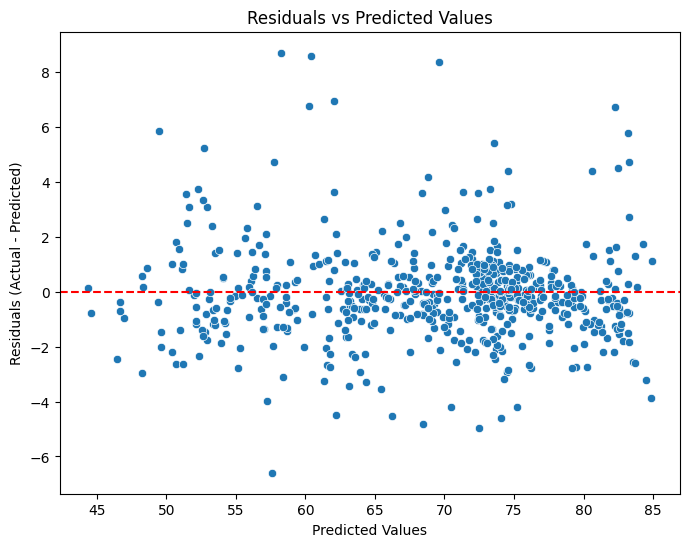

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have these:
# y_test : true values
# y_pred : predicted values by your Gradient Boosting model

# Calculate residuals
residuals = y_test - predictionsGB

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=predictionsGB, y=residuals)
plt.axhline(0, color='red', linestyle='--')  # horizontal line at 0
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals vs Predicted Values')
plt.show()


Feature importance plot

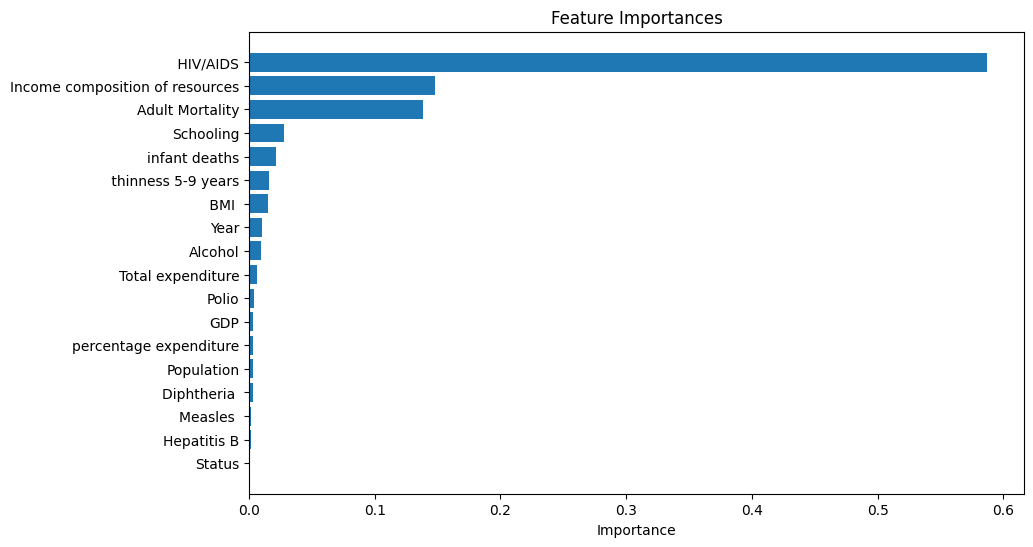

In [63]:
import numpy as np

# Assuming 'model' is your trained GradientBoostingRegressor
feature_importances = best_model.feature_importances_
features = X_train.columns  # if your input is a DataFrame

# Sort features by importance
indices = np.argsort(feature_importances)

plt.figure(figsize=(10,6))
plt.barh(features[indices], feature_importances[indices])
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.show()


learning curve

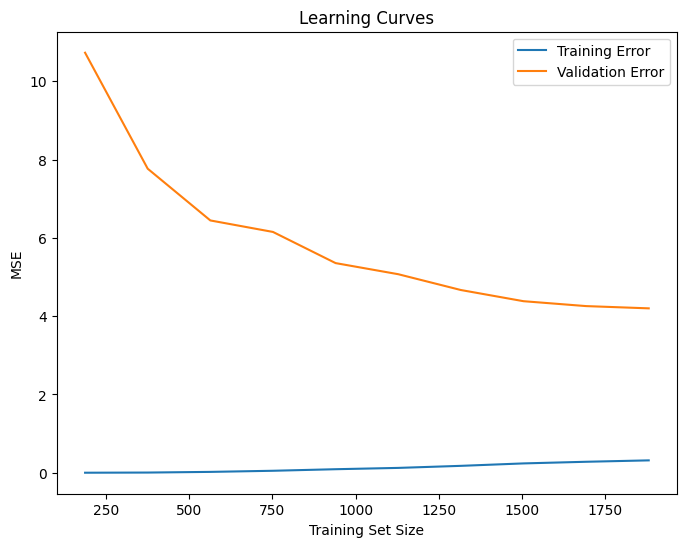

In [64]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1)

train_errors = -train_scores.mean(axis=1)
val_errors = -val_scores.mean(axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_errors, label='Training Error')
plt.plot(train_sizes, val_errors, label='Validation Error')
plt.xlabel('Training Set Size')
plt.ylabel('MSE')
plt.title('Learning Curves')
plt.legend()
plt.show()


Error Distribution

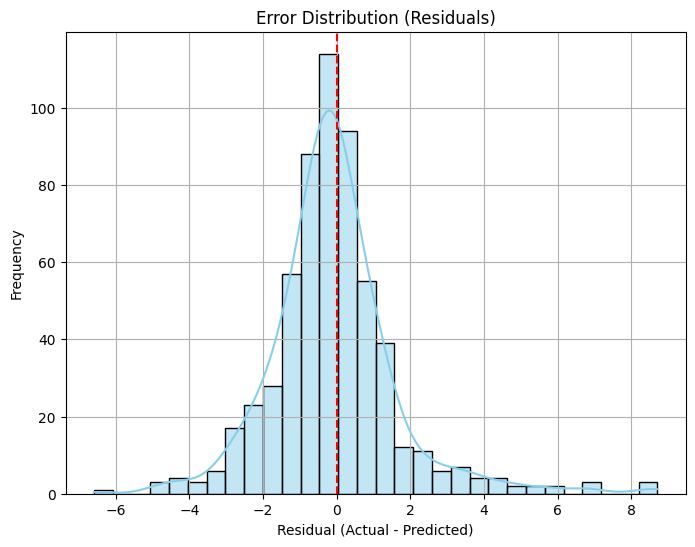

In [65]:


# Assuming you already have:
# y_test : true target values
# y_pred : predicted target values

# Step 1: Calculate residuals
residuals = y_test - predictionsGB

# Step 2: Plot
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, bins=30, color='skyblue')
plt.axvline(0, color='red', linestyle='--')  # Line at 0 error
plt.title('Error Distribution (Residuals)')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


In [66]:
import numpy as np
import matplotlib.pyplot as plt

# Normalize features for better convergence
X_norm = (X - X.mean()) / X.std()
X_norm.insert(0, 'Intercept', 1)  # Add bias term
X_matrix = X_norm.values
y_vector = y.values.reshape(-1, 1)

# Initialize parameters
theta = np.zeros((X_matrix.shape[1], 1))
alpha = 0.01
iterations = 1000
m = len(y_vector)

# Cost function history
cost_history = []

# Gradient descent loop
for i in range(iterations):
    predictions = X_matrix @ theta
    errors = predictions - y_vector
    cost = (1/(2*m)) * np.sum(errors**2)
    cost_history.append(cost)
    gradients = (1/m) * X_matrix.T @ errors
    theta -= alpha * gradients


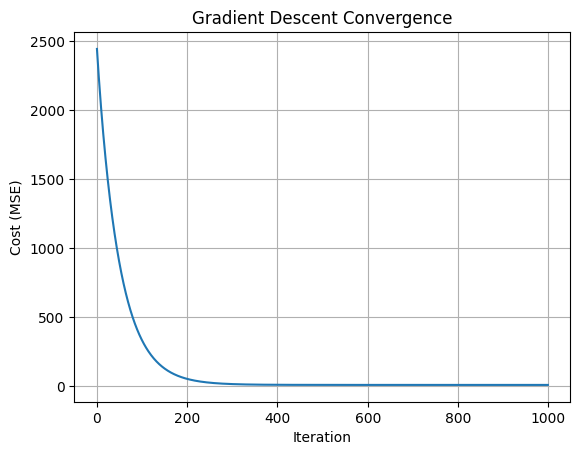

In [67]:
plt.plot(range(iterations), cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE)")
plt.title("Gradient Descent Convergence")
plt.grid(True)
plt.show()


DECISION TREE REGRESSION

In [68]:
np.where(X.columns == 'Schooling')

(array([17]),)

Text(0.5, 0, 'Schooling')

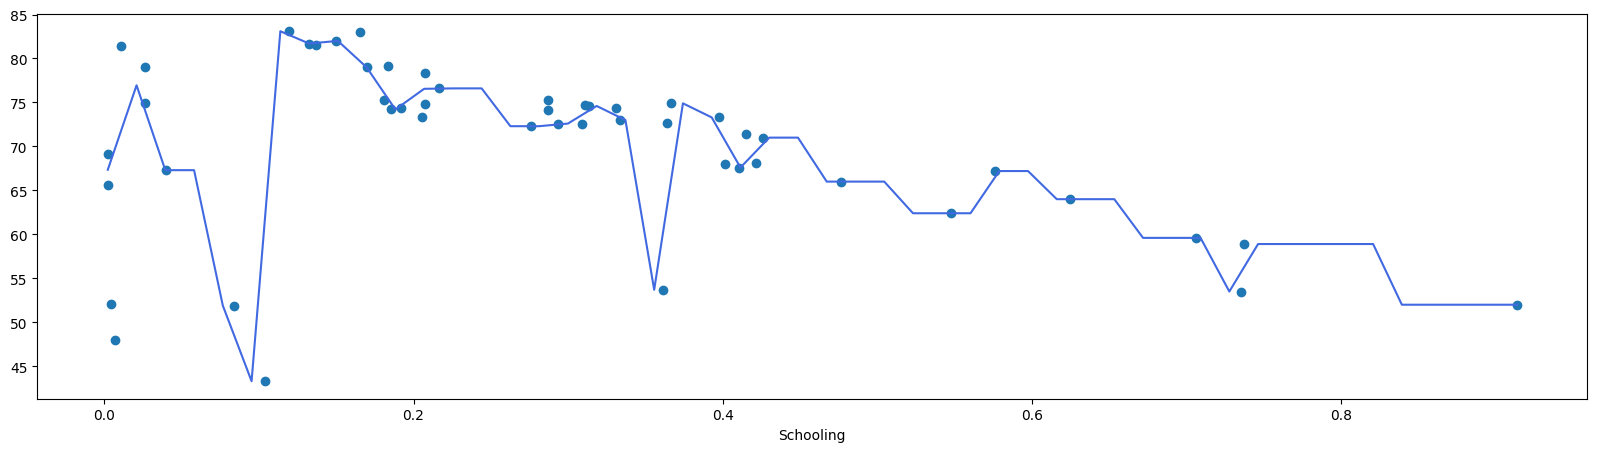

In [69]:
from sklearn.tree import DecisionTreeRegressor

X_train_school = X_train[['Schooling']]
y_b = y_train[:50]

clf = DecisionTreeRegressor()
clf.fit(X_b, y_b)

X_new=np.linspace(X_b.min(), X_b.max(), 50).reshape(50, 1)
y_predict = clf.predict(X_new)

plt.subplots(figsize = (20,5))
plt.plot(X_new, y_predict, c = 'royalblue')
plt.scatter(X_b, y_b)
plt.xlabel('Schooling')

In [70]:
from sklearn.tree import DecisionTreeRegressor

dt_train_score=[]
dt_test_score=[]

for i in range(1,15):
    dtregressor = DecisionTreeRegressor(max_depth=i,random_state= 0)
    dtregressor.fit(X_train, y_train)
    dt_train_score.append(dtregressor.score(X_train, y_train))
    dt_test_score.append(dtregressor.score(X_test, y_test))

In [71]:
print(dt_train_score)
print(dt_test_score)

[0.5770359504010478, 0.7247276704741501, 0.8119834687103611, 0.8717573122446292, 0.9092618704231316, 0.9322420211847076, 0.9490159049820387, 0.9647873273976764, 0.9772096992671983, 0.9863665378297349, 0.9916459199274127, 0.9950047747958426, 0.997548225360126, 0.9988039567401346]
[0.5762473513686819, 0.7192963289501169, 0.8057457363060417, 0.8631912488329218, 0.9008069131229346, 0.9141150768624261, 0.926998673547891, 0.925068560187544, 0.9286788590481888, 0.9140755982001374, 0.9200578039725841, 0.9209109715578165, 0.9146654004640716, 0.9172718346761287]


Text(0, 0.5, 'Accuracy')

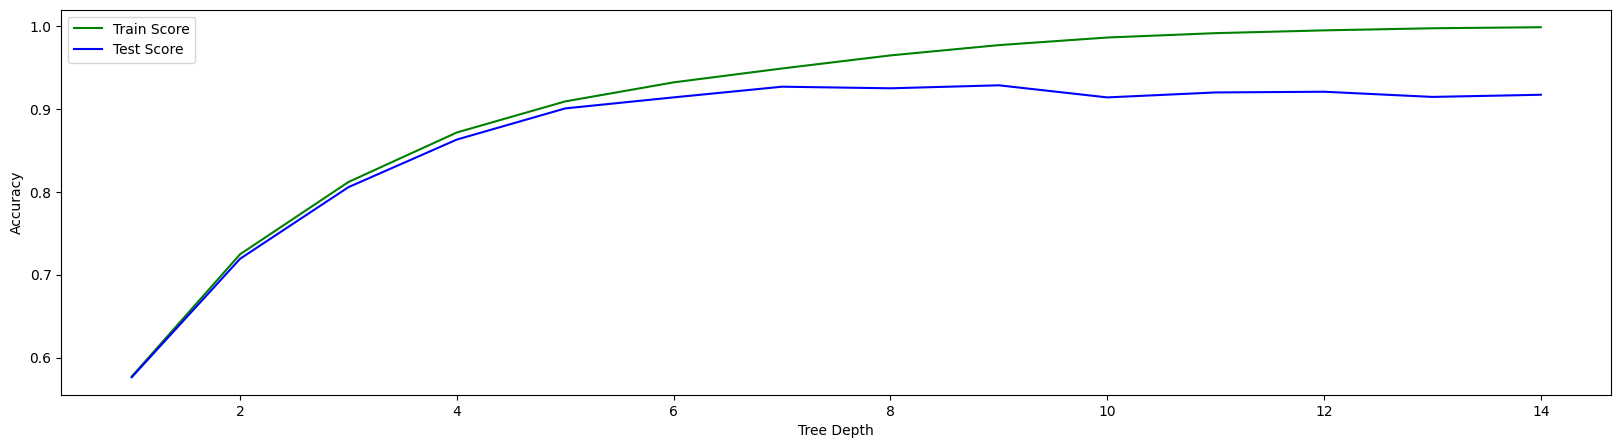

In [72]:
x_axis = range(1,15)
plt.subplots(figsize = (20,5))
plt.plot(x_axis, dt_train_score, c = 'g', label = 'Train Score')
plt.plot(x_axis, dt_test_score, c = 'b', label = 'Test Score')
plt.legend()
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')


Just visualizing, the best hyperparameter depth seems to be 6 because it has high train and test scores and a small gap between train and test scores

In [73]:
dtregressor = DecisionTreeRegressor(max_depth=6)
dtregressor.fit(X_train, y_train)
ydt_predicted = dtregressor.predict(X_test)

print('Train score: {:.4f}'.format(dtregressor.score(X_train, y_train)))
print('Test score: {:.4f}'.format(dtregressor.score(X_test, y_test)))
print('R2_score: {:.4f}'.format(r2_score(y_test,ydt_predicted)))
MSE = np.square(np.subtract(y_test,ydt_predicted)).mean()
print('MSE: {:.4f}'.format(MSE))

Train score: 0.9322
Test score: 0.9155
R2_score: 0.9155
MSE: 7.3200


**Use GridSearch to find the best hyperparameters for Decision Tree Regressor**

In [74]:
#We have considered a few of the hyperparameters here to find which could be the best
dt_param_grid = {'max_depth' : range(1,10),'min_samples_leaf' : range(1,10), 'criterion':['squared_error','absolute_error', 'friedman_mse'], 'splitter': ['best', 'random']}

dtregressor = DecisionTreeRegressor(random_state=0)
dt_best_reg = GridSearchCV(estimator = dtregressor, param_grid = dt_param_grid , return_train_score=True)
dt_best_reg.fit(X_train, y_train)

dt_best_params = dt_best_reg.best_params_
print(dt_best_params)

{'criterion': 'friedman_mse', 'max_depth': 9, 'min_samples_leaf': 7, 'splitter': 'best'}


In [75]:
best_dt_reg = DecisionTreeRegressor(criterion='squared_error', max_depth= 9, min_samples_leaf= 3, splitter= 'best')
best_dt_reg.fit(X_train, y_train)
ydt_predicted = best_dt_reg.predict(X_test)

print('Train score: {:.4f}'.format(best_dt_reg.score(X_train, y_train)))
print('Test score: {:.4f}'.format(best_dt_reg.score(X_test, y_test)))
print('R2_score: {:.4f}'.format(r2_score(y_test,ydt_predicted)))
MSE = np.square(np.subtract(y_test,ydt_predicted)).mean()
print('MSE: {:.4f}'.format(MSE))

Train score: 0.9737
Test score: 0.9354
R2_score: 0.9354
MSE: 5.5941


The chosen paramters for the decision tree has a very good train and test score and also has a relatively low MSE. Decision Trees are prone to overfitting. But as the depth increases, the model will traverse entirely and the train and test scores will obviously get better because the model is now overfit. We need an early stopping condition i.e we need to reduce the depth

Building an ANN model 

In [76]:
model = Sequential([
        Dense(64, activation='relu', input_dim=18),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
])

In [77]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error','mean_squared_error'])

In [78]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,601 (37.50 KB)

 Trainable params: 9,601 (37.50 KB)

 Non-trainable params: 0 (0.00 B)

In [79]:
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [80]:
history = model.fit(X_train, y_train, epochs=150, validation_split=0.2)

Epoch 1/150
59/59 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 4456.9199 - mean_absolute_error: 65.7915 - mean_squared_error: 4456.9199 - val_loss: 548.8149 - val_mean_absolute_error: 21.3386 - val_mean_squared_error: 548.8149
Epoch 2/150
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 240.3275 - mean_absolute_error: 12.3851 - mean_squared_error: 240.3275 - val_loss: 96.0644 - val_mean_absolute_error: 7.8006 - val_mean_squared_error: 96.0644
Epoch 3/150
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 88.5521 - mean_absolute_error: 7.4748 - mean_squared_error: 88.5521 - val_loss: 77.1826 - val_mean_absolute_error: 6.9418 - val_mean_squared_error: 77.1826
Epoch 4/150
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 70.2709 - mean_absolute_error: 6.6260 - mean_squared_error: 70.2709 - val_loss: 63.1019 - val_mean_absolute_error: 6.2506 - val_mean_squared_error: 63.1019
Epoch 5/150
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 61.4308 - mean_absolute_error: 6.2083 - mean_squared_error: 61.4308

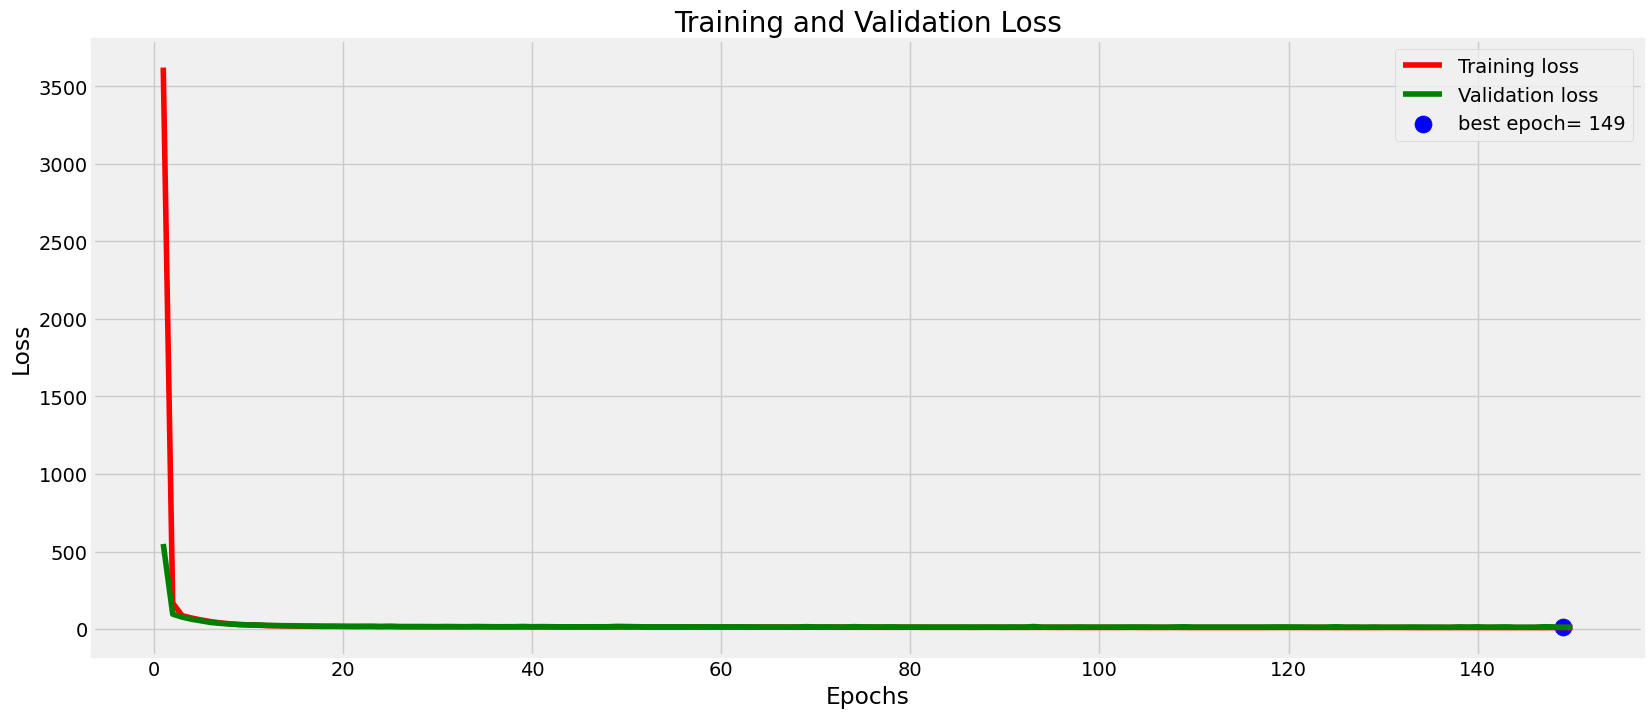

In [81]:
# Define needed variables
tr_loss = history.history['loss']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]

Epochs = [i+1 for i in range(len(tr_loss))]
loss_label = f'best epoch= {str(index_loss + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', 
            label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout
plt.show()

In [82]:
y_predann = model.predict(X_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [91]:
R2 = r2_score(y_test, y_predann)
print("R2 Score=",R2 )
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_predann)
print("MSE =", mse)

R2 Score= 0.8845804618510186
MSE = 9.999403648062696



## ANALYZING BEST REGRESSION MODEL

In [92]:
print('MSE Linear Regression: {:.4f}'.format(mean_squared_error(y_test,ylin_predicted)))
print('MSE Polynomial Regression: {:.4f}'.format(mean_squared_error(y_test,y_pred_poly)))
print('MSE Gradient Boost Regression: {:.4f}'.format(mean_squared_error(y_test,predictionsGB)))
print('MSE ANN: {:.4f}'.format(mean_squared_error(y_test,y_predann)))

MSE Linear Regression: 12.5640
MSE Polynomial Regression: 8.5350
MSE Gradient Boost Regression: 2.9880
MSE ANN: 9.9994


In [93]:
import pandas as pd
from sklearn.metrics import mean_squared_error

# Store model names and their corresponding MSEs
mse_results = {
 
    'Linear Regression': mean_squared_error(y_test, ylin_predicted),
    'Polynomial Regression': mean_squared_error(y_test, y_pred_poly),
    'Gradient Boosting': mean_squared_error(y_test, predictionsGB),
    'ANN': mean_squared_error(y_test, y_predann)
}

# Convert to DataFrame for a clean display
mse_df = pd.DataFrame(list(mse_results.items()), columns=['Model', 'MSE']).sort_values(by='MSE')
print(mse_df)

                   Model        MSE
2      Gradient Boosting   2.987952
1  Polynomial Regression   8.534969
3                    ANN   9.999404
0      Linear Regression  12.563976


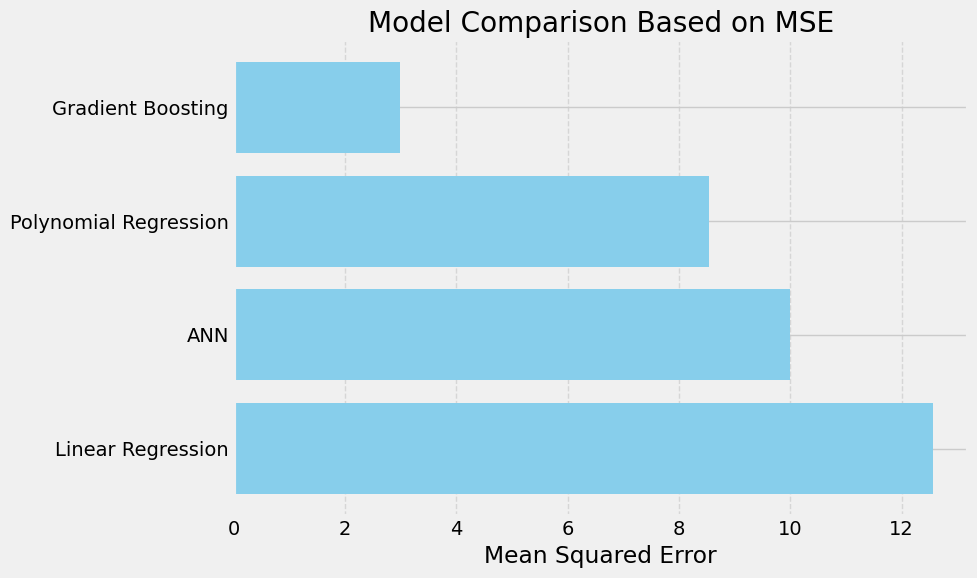

In [94]:
import matplotlib.pyplot as plt

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(mse_df['Model'], mse_df['MSE'], color='skyblue')
plt.xlabel('Mean Squared Error')
plt.title('Model Comparison Based on MSE')
plt.gca().invert_yaxis()  # So the best model (lowest MSE) appears on top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [98]:
print('R2 Square score Linear Regression: {:.4f}'.format(r2_score(y_test,ylin_predicted)))
print('R2 Square score Polynomial Regression: {:.4f}'.format(r2_score(y_test,y_pred_poly)))
print('R2 Square score Gradient Boost Regression : {:.4f}'.format(r2_score(y_test,predictionsGB)))
print('R2 Square ANN: {:.4f}'.format(r2_score(y_test,y_predann)))

R2 Square score Linear Regression: 0.8550
R2 Square score Polynomial Regression: 0.9015
R2 Square score Gradient Boost Regression : 0.9655
R2 Square ANN: 0.8846


In [96]:
r2_results = {
    'Linear Regression': r2_score(y_test, ylin_predicted),
    'Polynomial Regression': r2_score(y_test, y_pred_poly),
    'Gradient Boosting': r2_score(y_test, predictionsGB),
    'ANN': r2_score(y_test, y_predann)
}

# Convert to DataFrame for a clean display
r2_df = pd.DataFrame(list(r2_results.items()), columns=['Model', 'R2 score']).sort_values(by='R2 score')
print(r2_df)

                   Model  R2 score
0      Linear Regression  0.854979
3                    ANN  0.884580
1  Polynomial Regression  0.901484
2      Gradient Boosting  0.965511


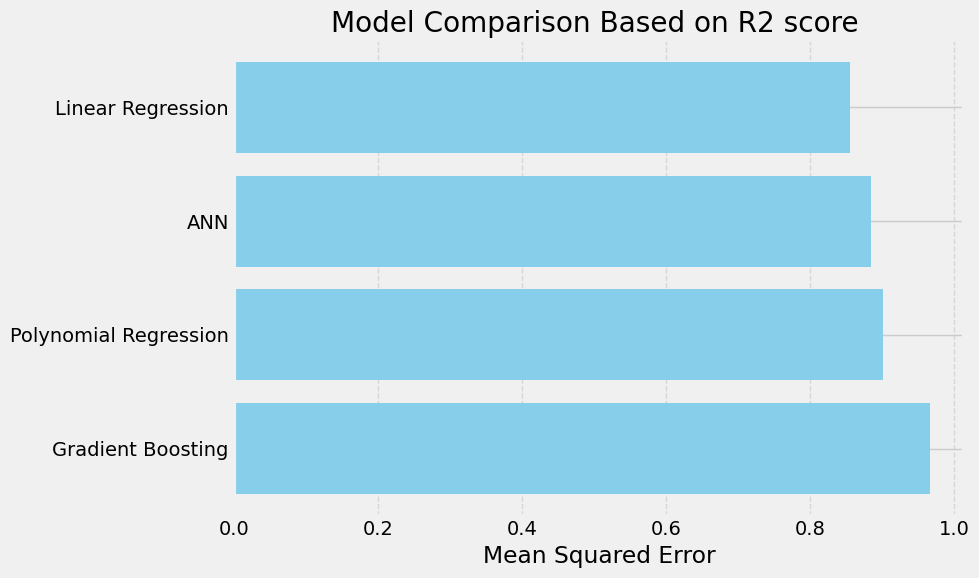

In [97]:
# Plotting
plt.figure(figsize=(10, 6))
plt.barh(r2_df['Model'], r2_df['R2 score'], color='skyblue')
plt.xlabel('Mean Squared Error')
plt.title('Model Comparison Based on R2 score ')
plt.gca().invert_yaxis()  # So the best model (lowest MSE) appears on top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Annexe

In [84]:
print('MSE KNN Regression: {:.4f}'.format(mean_squared_error(y_test,y_predicted)))
print('MSE Linear Regression: {:.4f}'.format(mean_squared_error(y_test,ylin_predicted)))
print('MSE Random Forrest : {:.4f}'.format(mean_squared_error(y_test,y_predRF)))
print('MSE Gradient Boost Regression: {:.4f}'.format(mean_squared_error(y_test,predictionsGB)))
print('MSE ANN: {:.4f}'.format(mean_squared_error(y_test,y_predann)))
print('MSE Polynomial Regression: {:.4f}'.format(mean_squared_error(y_test,y_pred_poly)))
print('MSE Decision Tree Rgression: {:.4f}'.format(mean_squared_error(y_test,ydt_predicted)))

MSE KNN Regression: 4.5413
MSE Linear Regression: 12.5640
MSE Random Forrest : 2.9494
MSE Gradient Boost Regression: 2.9880
MSE ANN: 9.9994
MSE Polynomial Regression: 8.5350
MSE Decision Tree Rgression: 5.5941


In [85]:
import pandas as pd
from sklearn.metrics import mean_squared_error

# Store model names and their corresponding MSEs
mse_results = {
    'KNN Regression': mean_squared_error(y_test, y_predicted),
    'Linear Regression': mean_squared_error(y_test, ylin_predicted),
    'Random Forest': mean_squared_error(y_test, y_predRF),
    'Gradient Boosting': mean_squared_error(y_test, predictionsGB),
    'ANN': mean_squared_error(y_test, y_predann),
    'Polynomial Regression': mean_squared_error(y_test, y_pred_poly),
    'Decision Tree': mean_squared_error(y_test, ydt_predicted)
}

# Convert to DataFrame for a clean display
mse_df = pd.DataFrame(list(mse_results.items()), columns=['Model', 'MSE']).sort_values(by='MSE')
print(mse_df)


                   Model        MSE
2          Random Forest   2.949352
3      Gradient Boosting   2.987952
0         KNN Regression   4.541258
6          Decision Tree   5.594106
5  Polynomial Regression   8.534969
4                    ANN   9.999404
1      Linear Regression  12.563976


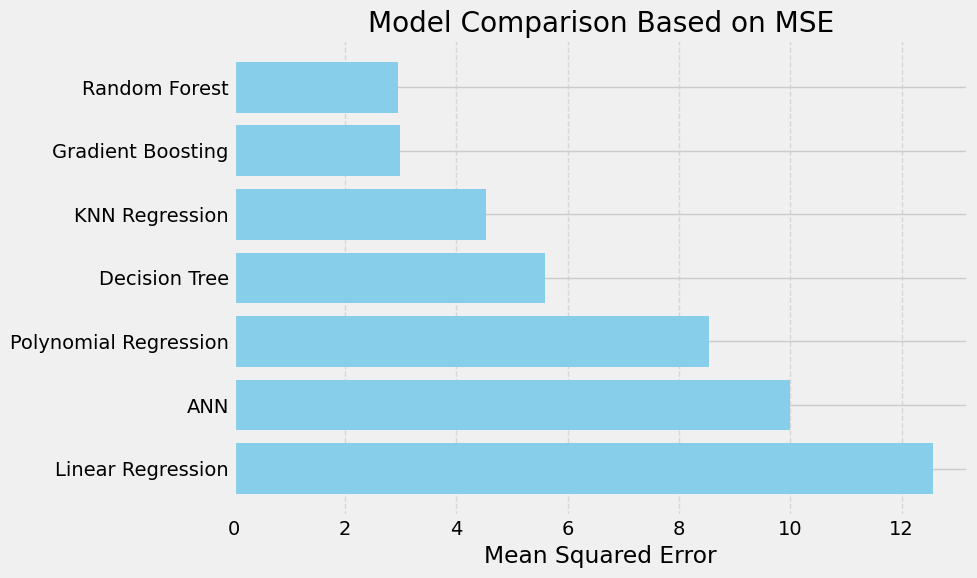

In [86]:
import matplotlib.pyplot as plt

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(mse_df['Model'], mse_df['MSE'], color='skyblue')
plt.xlabel('Mean Squared Error')
plt.title('Model Comparison Based on MSE')
plt.gca().invert_yaxis()  # So the best model (lowest MSE) appears on top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



Smallest MSE is for KNN, Decision Tree Regression but we know that both these models overfit the data

In [87]:
print('R2 Square score KNN Regression: {:.4f}'.format(r2_score(y_test,y_predicted)))
print('R2 Square score Linear Regression: {:.4f}'.format(r2_score(y_test,ylin_predicted)))
print('R2 Square score Random forrest : {:.4f}'.format(r2_score(y_test,y_predRF)))
print('R2 Square score Gradient Boost Regression : {:.4f}'.format(r2_score(y_test,predictionsGB)))
print('R2 Square ANN: {:.4f}'.format(r2_score(y_test,y_predann)))
print('R2 Square score Polynomial Regression: {:.4f}'.format(r2_score(y_test,y_pred_poly)))
print('R2 Square score Decision Tree Regression: {:.4f}'.format(r2_score(y_test,ydt_predicted)))

R2 Square score KNN Regression: 0.9476
R2 Square score Linear Regression: 0.8550
R2 Square score Random forrest : 0.9660
R2 Square score Gradient Boost Regression : 0.9655
R2 Square ANN: 0.8846
R2 Square score Polynomial Regression: 0.9015
R2 Square score Decision Tree Regression: 0.9354


In [88]:
r2_results = {
    'KNN Regression': r2_score(y_test, y_predicted),
    'Linear Regression': r2_score(y_test, ylin_predicted),
    'Random Forest': r2_score(y_test, y_predRF),
    'Gradient Boosting': r2_score(y_test, predictionsGB),
    'ANN': r2_score(y_test, y_predann),
    'Polynomial Regression': r2_score(y_test, y_pred_poly),
    'Decision Tree': r2_score(y_test, ydt_predicted)
}

# Convert to DataFrame for a clean display
r2_df = pd.DataFrame(list(r2_results.items()), columns=['Model', 'R2 score']).sort_values(by='R2 score')
print(r2_df)

                   Model  R2 score
1      Linear Regression  0.854979
4                    ANN  0.884580
5  Polynomial Regression  0.901484
6          Decision Tree  0.935429
0         KNN Regression  0.947582
3      Gradient Boosting  0.965511
2          Random Forest  0.965957


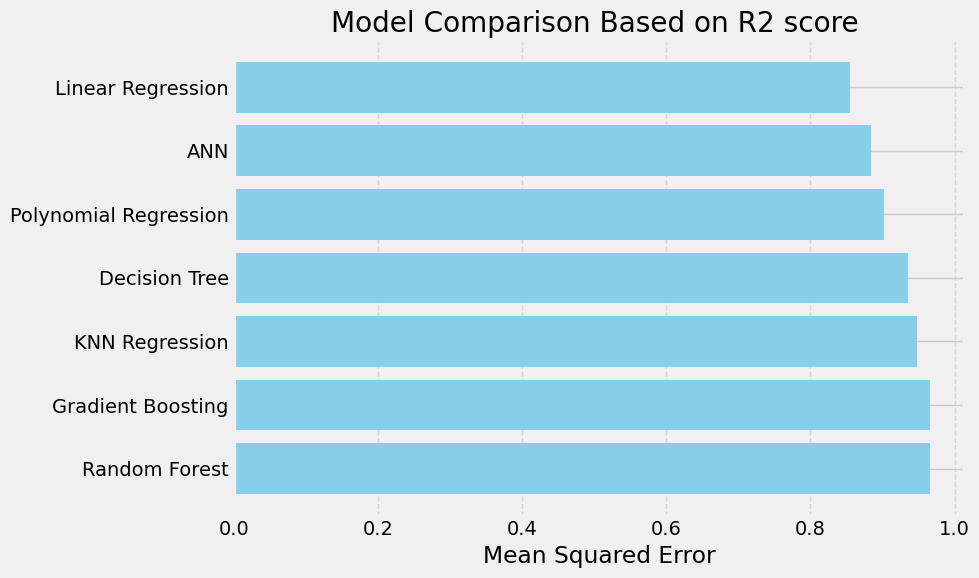

In [ ]:
# Plotting
plt.figure(figsize=(10, 6))
plt.barh(r2_df['Model'], r2_df['R2 score'], color='skyblue')
plt.xlabel('R2 score')
plt.title('Model Comparison Based on R2 score ')
plt.gca().invert_yaxis()  # So the best model (lowest MSE) appears on top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Best R2 score values are for KNN, Polynomial Regression, Decision Tree and Kernel rbf. But we know that KNN and Decision Tree Regression overfit the data

BONUS 

In [90]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'KNN Regressor': KNeighborsRegressor(n_neighbors=5),
    'SVR (RBF kernel)': SVR(kernel='rbf'),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
}


results = []

# Evaluate each model
for name, model in models.items():
    # Use scaled data for models that require it
    if name in ['KNN Regressor', 'SVR (RBF kernel)', 'MLP Regressor']:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)

    results.append({
        'Model': name,
        'R2 Score': round(r2, 4),
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4)
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print(results_df.sort_values(by='R2 Score', ascending=False).reset_index(drop=True))

               Model  R2 Score    RMSE     MAE
0      Random Forest    0.9654  1.7307  1.0807
1      KNN Regressor    0.9033  2.8948  2.0057
2      MLP Regressor    0.8994  2.9521  2.0878
3   SVR (RBF kernel)    0.8937  3.0342  2.1833
4   Ridge Regression    0.8553  3.5408  2.6798
5  Linear Regression    0.8550  3.5446  2.6837
6   Lasso Regression    0.8471  3.6393  2.7169
